# Fraud Detection – Exploratory Data Analysis (EDA)
## Dataset: Fraud_Data.csv (E-commerce Transactions)

This notebook covers **Task-1: Data Analysis and Preprocessing** for the
e-commerce fraud dataset.

Goal:
- Understand the data
- Clean the data
- Explore fraud patterns
- Prepare the data for machine learning


## Business Context

Adey Innovations Inc. works with e-commerce platforms.
Fraudulent transactions cause:
- Financial loss
- Loss of customer trust

Our goal is to analyze transaction data and understand:
- How fraud happens
- What patterns indicate fraud
- How to prepare the data for modeling


## Step 1: Import Required Libraries

We import Python libraries that help us:
- Load data
- Analyze data
- Visualize patterns


In [1]:
import os
import sys

project_root = r"C:\Users\Y\Downloads\fraud-detection"
os.chdir(project_root)
print("Working directory:", os.getcwd())

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Fraud_Data.csv found?", os.path.exists("data/raw/Fraud_Data.csv"))

Working directory: C:\Users\Y\Downloads\fraud-detection
Fraud_Data.csv found? True


In [4]:
import os
import sys

# Hard-code your real project root (copy-paste from your PS prompt)
project_root = r"C:\Users\Y\Downloads\fraud-detection"

# Change to it
os.chdir(project_root)
print("Now changed to:", os.getcwd())

# Quick check: list some expected folders/files
print("Contents of current dir:", os.listdir('.')[:10])  # should show 'data', 'notebooks', 'src', etc.
print("data folder exists?", os.path.isdir("data"))
print("raw folder exists?", os.path.isdir("data/raw"))

# Verify the exact files
print("Fraud_Data.csv exists?", os.path.exists("data/raw/Fraud_Data.csv"))
print("Full path:", os.path.abspath("data/raw/Fraud_Data.csv"))

print("IpAddress_to_Country.csv exists?", os.path.exists("data/raw/IpAddress_to_Country.csv"))
print("Full path:", os.path.abspath("data/raw/IpAddress_to_Country.csv"))

# Make src importable
if project_root not in sys.path:
    sys.path.insert(0, project_root)

Now changed to: C:\Users\Y\Downloads\fraud-detection
Contents of current dir: ['.git', '.github', '.gitignore', '.pytest_cache', '.qodo', '.vscode', 'data', 'figures', 'models', 'notebooks']
data folder exists? True
raw folder exists? True
Fraud_Data.csv exists? True
Full path: C:\Users\Y\Downloads\fraud-detection\data\raw\Fraud_Data.csv
IpAddress_to_Country.csv exists? True
Full path: C:\Users\Y\Downloads\fraud-detection\data\raw\IpAddress_to_Country.csv


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from src.preprocessing import preprocess_fraud_full
sns.set(style="whitegrid")
df = preprocess_fraud_full(save=True)

Removed 0 duplicates
Missing values: 0 (none expected)
Cleaned shape for modeling: (151112, 196)
Final columns: ['age', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'class', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Burundi', 'country_Cambodia', 'country_Cameroon', 'country_Canada', 'country_Cape Verde', 'country_Cayman Islands', 'country_Chile', 'country_China', 'country_Colombia'

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing import preprocess_fraud_full

sns.set(style="whitegrid")

# Task 1: Exploratory Data Analysis - E-Commerce Fraud Data
Objective: Univariate, bivariate, and class imbalance analysis on raw/processed data.

In [7]:
# Run full preprocessing pipeline (loads raw, cleans, engineers, transforms, saves)
df = preprocess_fraud_full(save=True)

Removed 0 duplicates
Missing values: 0 (none expected)
Cleaned shape for modeling: (151112, 196)
Final columns: ['age', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'class', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Burundi', 'country_Cambodia', 'country_Cameroon', 'country_Canada', 'country_Cape Verde', 'country_Cayman Islands', 'country_Chile', 'country_China', 'country_Colombia'

## 1. Data Cleaning Summary
- Duplicates removed
- Missing values checked
- Data types corrected (datetime, int for IP)

In [8]:
print(f"Final shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Fraud rate: {df['class'].mean():.2%}")

Final shape: 151,112 rows, 196 columns
Fraud rate: 9.36%


## 2. Class Distribution Analysis (Imbalance Quantification)
Highly imbalanced — fraud only ~9.36%.

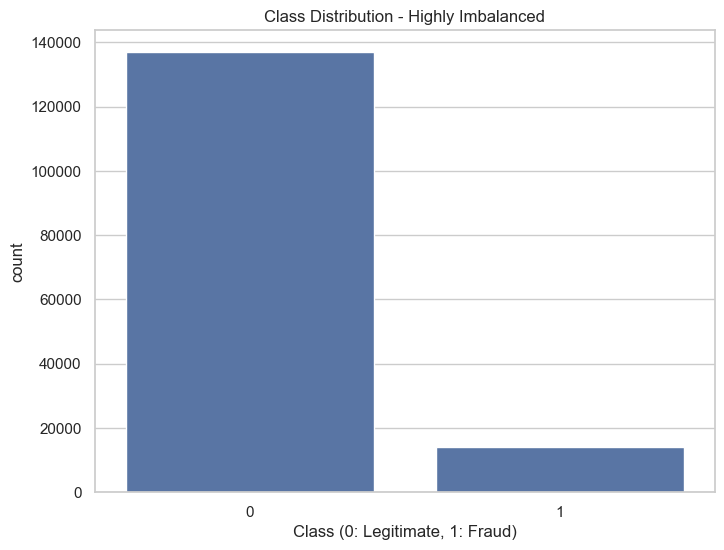

In [9]:
plt.figure(figsize=(8,6))
sns.countplot(x="class", data=df)
plt.title("Class Distribution - Highly Imbalanced")
plt.xlabel("Class (0: Legitimate, 1: Fraud)")
plt.show()

## 3. Univariate Analysis - Key Variables
Distributions of purchase value, age, source, browser.

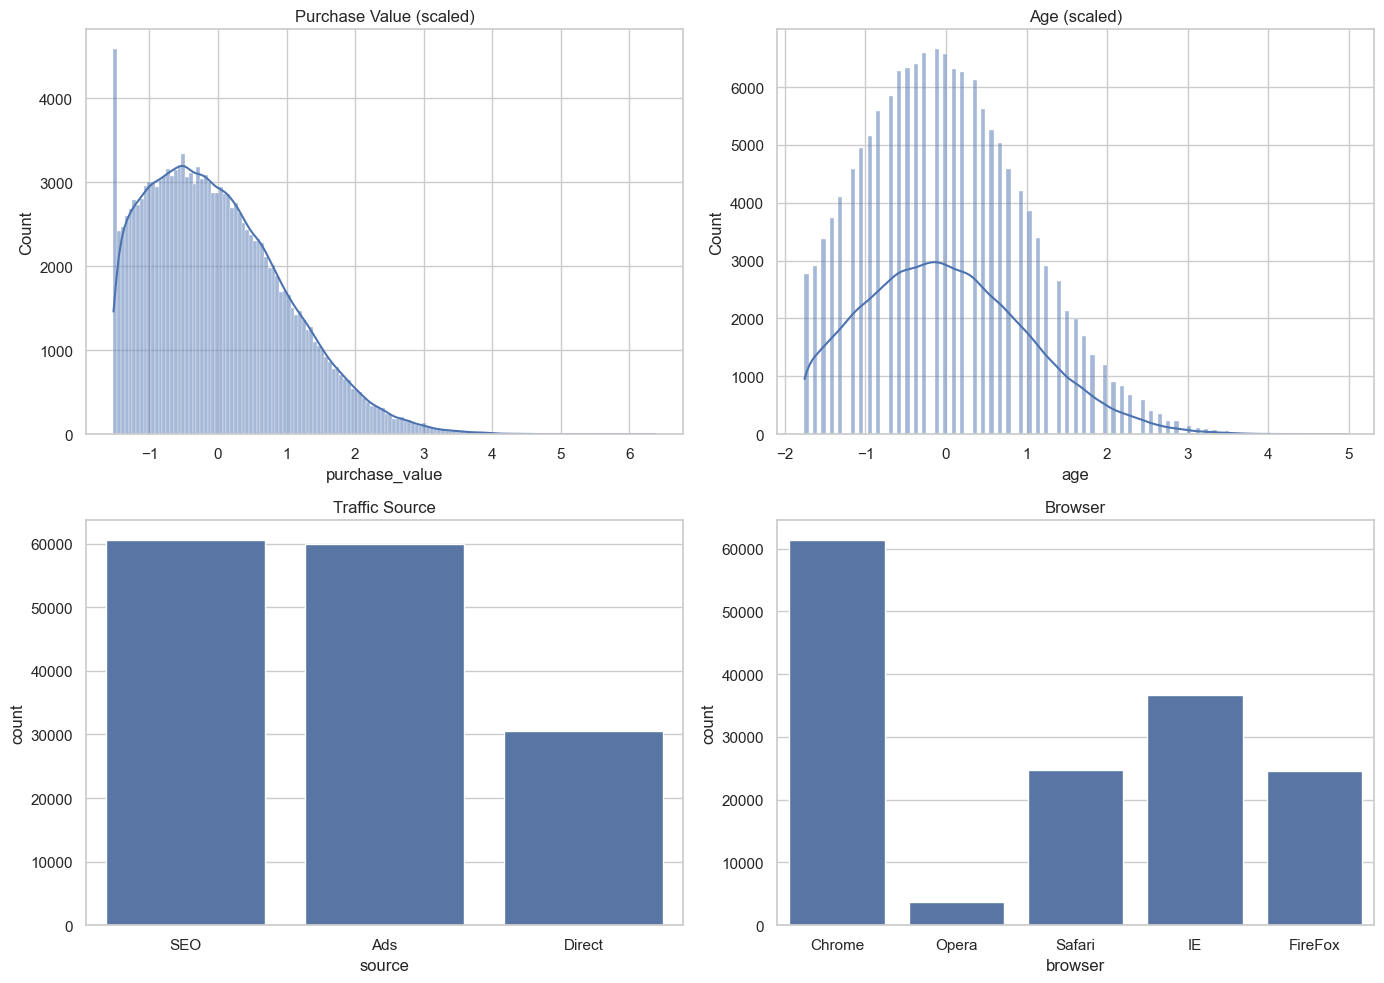

In [10]:
# Use raw for categorical counts (unscaled)
raw_df = pd.read_csv("data/raw/Fraud_Data.csv")

fig, ax = plt.subplots(2, 2, figsize=(14,10))
sns.histplot(df["purchase_value"], kde=True, ax=ax[0,0])  # Scaled
ax[0,0].set_title("Purchase Value (scaled)")
sns.histplot(df["age"], kde=True, ax=ax[0,1])
ax[0,1].set_title("Age (scaled)")
sns.countplot(x="source", data=raw_df, ax=ax[1,0])
ax[1,0].set_title("Traffic Source")
sns.countplot(x="browser", data=raw_df, ax=ax[1,1])
ax[1,1].set_title("Browser")
plt.tight_layout()
plt.show()

## 4. Bivariate Analysis - Features vs Target
Relationships with fraud class.

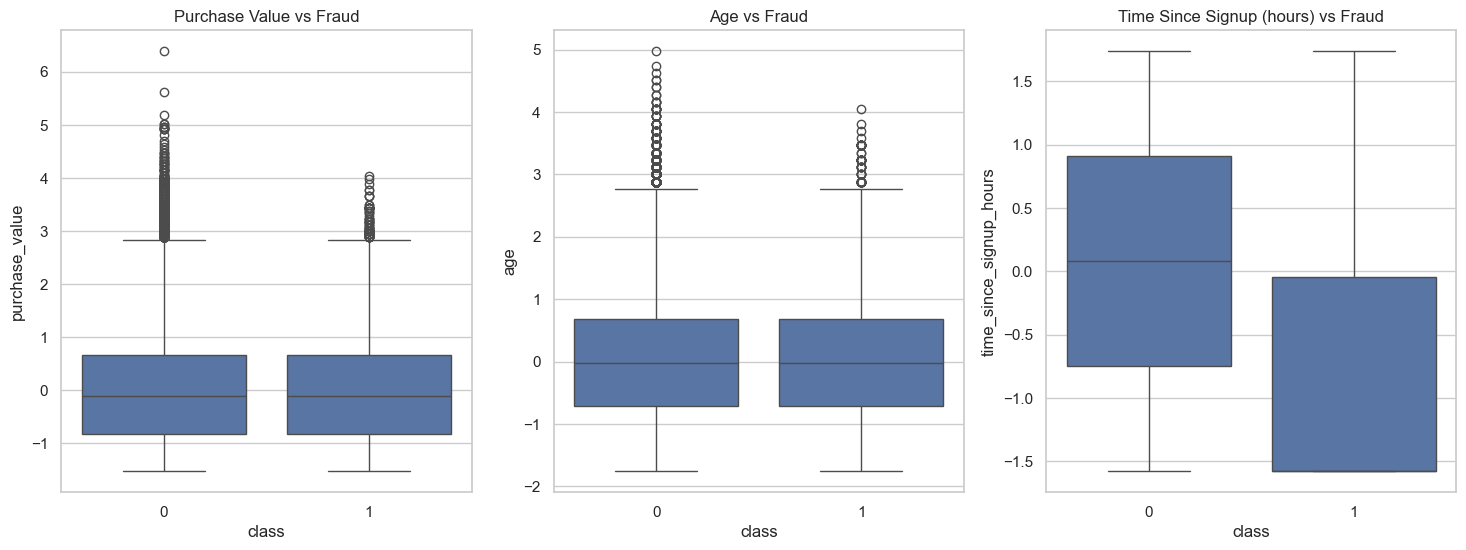

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18,6))
sns.boxplot(x="class", y="purchase_value", data=df, ax=ax[0])
ax[0].set_title("Purchase Value vs Fraud")
sns.boxplot(x="class", y="age", data=df, ax=ax[1])
ax[1].set_title("Age vs Fraud")
sns.boxplot(x="class", y="time_since_signup_hours", data=df, ax=ax[2])
ax[2].set_title("Time Since Signup (hours) vs Fraud")
plt.show()

## 3. Geolocation Analysis – Fraud Patterns by Country

We use the raw `country` column (before one-hot encoding) to analyze fraud rates per country.
Only countries with at least 100 transactions are shown to avoid noisy results.

In [10]:
# Import the specific function we need from src/preprocessing.py
from src.preprocessing import add_geolocation

C:\Users\Y\AppData\Local\Temp\ipykernel_19644\994714225.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


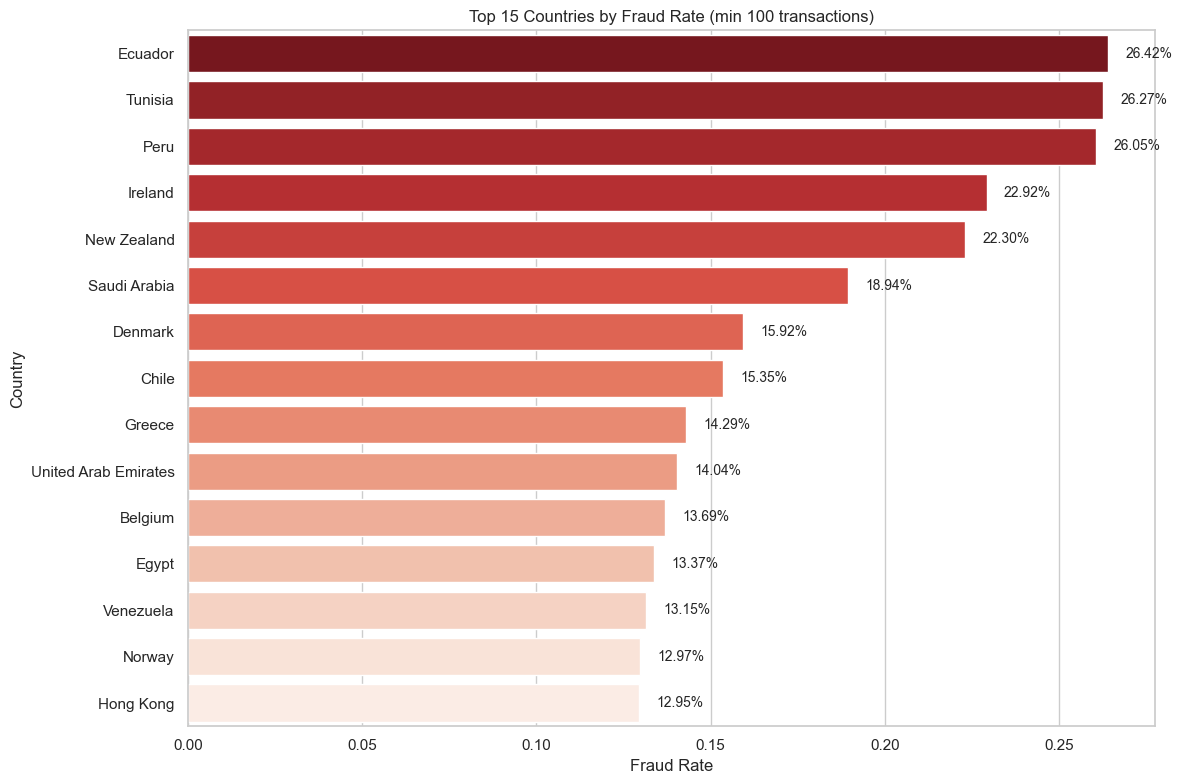

Top 15 countries by fraud rate:
             country  total_tx  fraud_rate
             Ecuador       106    0.264151
             Tunisia       118    0.262712
                Peru       119    0.260504
             Ireland       240    0.229167
         New Zealand       278    0.223022
        Saudi Arabia       264    0.189394
             Denmark       490    0.159184
               Chile       417    0.153477
              Greece       231    0.142857
United Arab Emirates       114    0.140351
             Belgium       409    0.136919
               Egypt       359    0.133705
           Venezuela       251    0.131474
              Norway       609    0.129721
           Hong Kong       471    0.129512


In [11]:
# Reload raw data + apply only geolocation & minimal cleaning (no encoding/scaling)
df_raw_geo = pd.read_csv("data/raw/Fraud_Data.csv")
df_raw_geo = add_geolocation(df_raw_geo)  # reuse your existing function

# Aggregate: count + fraud rate per country
country_stats = df_raw_geo.groupby('country').agg(
    total_tx=('class', 'count'),
    fraud_rate=('class', 'mean')
).reset_index()

# Filter: only countries with ≥ 100 transactions
country_stats_filtered = country_stats[country_stats['total_tx'] >= 100]

# Sort by fraud rate descending
top_fraud_countries = country_stats_filtered.sort_values('fraud_rate', ascending=False).head(15)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_fraud_countries,
    x='fraud_rate',
    y='country',
    palette='Reds_r'
)
plt.title('Top 15 Countries by Fraud Rate (min 100 transactions)')
plt.xlabel('Fraud Rate')
plt.ylabel('Country')

# Add percentage labels
for i, v in enumerate(top_fraud_countries['fraud_rate']):
    plt.text(v + 0.005, i, f'{v:.2%}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Top 15 countries by fraud rate:")
print(top_fraud_countries[['country', 'total_tx', 'fraud_rate']].to_string(index=False))

## 4. Class Imbalance – Visual Quantification

The dataset shows severe class imbalance (~9.36% fraud).
This visualization confirms the problem and motivates our resampling strategy.

C:\Users\Y\AppData\Local\Temp\ipykernel_19644\2840052821.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, ax=ax2, palette=['#66c2a5', '#fc8d62'])


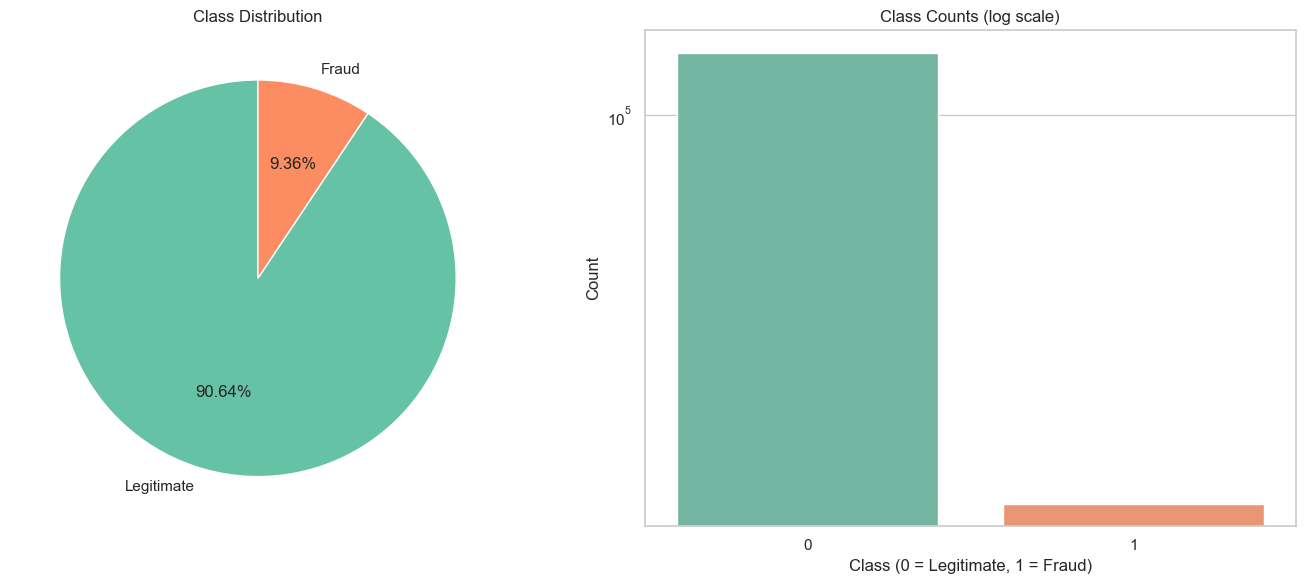

In [12]:
# Class distribution pie + bar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
df['class'].value_counts().plot.pie(
    ax=ax1,
    autopct='%1.2f%%',
    labels=['Legitimate', 'Fraud'],
    colors=['#66c2a5', '#fc8d62'],
    startangle=90
)
ax1.set_title('Class Distribution')
ax1.set_ylabel('')

# Bar chart (log scale for better visibility)
sns.countplot(x='class', data=df, ax=ax2, palette=['#66c2a5', '#fc8d62'])
ax2.set_title('Class Counts (log scale)')
ax2.set_yscale('log')
ax2.set_xlabel('Class (0 = Legitimate, 1 = Fraud)')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 5. Class Imbalance Handling – SMOTE Demonstration

We apply **SMOTE only on the training set** to avoid data leakage.

**Justification**:
- The dataset is highly imbalanced (~9.36% fraud).
- Undersampling would discard too much legitimate data → loss of information.
- SMOTE generates synthetic examples for the minority class → preserves all legitimate samples.
- We do **not** apply it to the test set → realistic evaluation.
- Alternative approaches (class_weight in models) will be tested in modeling phase.

In [7]:
# This is the line that creates 'df'
df = preprocess_fraud_full(save=False)  # save=False during development
print("df shape:", df.shape)
print("df columns sample:", df.columns[:10].tolist())

Removed 0 duplicates
Missing values: 0 (none expected)
Fraud rate: 9.365% (highly imbalanced — will use SMOTE on train only)
Unknown countries rate: 14.54%
df shape: (151112, 202)
df columns sample: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'age', 'ip_address', 'class', 'ip_int', 'time_since_signup_hours']


In [9]:
# Drop original datetime columns (they are not numeric and SMOTE can't handle them)
X = df.drop(columns=['class', 'signup_time', 'purchase_time'], errors='ignore')
y = df['class']

In [11]:
# Drop non-numeric / high-cardinality ID columns that can't be used by SMOTE
X = df.drop(
    columns=[
        'class', 
        'signup_time', 
        'purchase_time',
        'user_id',          # string IDs
        'device_id',        # string IDs
        'ip_address',       # original IP (already used for country)
        'ip_int'            # temporary column from geolocation
    ], 
    errors='ignore'         # safe if some don't exist
)
y = df['class']

In [12]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

# Prepare features: drop target + all non-numeric / unusable columns
X = df.drop(
    columns=[
        'class', 
        'signup_time', 
        'purchase_time',
        'user_id',
        'device_id',
        'ip_address',
        'ip_int'
    ], 
    errors='ignore'
)
y = df['class']

# Quick diagnostic — make sure only numeric columns remain
print("Remaining columns in X:", X.columns.tolist())
print("All numeric?", X.select_dtypes(include='number').shape[1] == X.shape[1])

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\n=== Before SMOTE (training set) ===")
print(y_train.value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

# Apply SMOTE only on train
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\n=== After SMOTE (training set) ===")
print(pd.Series(y_train_res).value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

print(f"\nTraining samples increased from {len(y_train):,} to {len(y_train_res):,}")

Remaining columns in X: ['purchase_value', 'age', 'time_since_signup_hours', 'hour_of_day', 'day_of_week', 'tx_per_user', 'tx_per_device', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Burundi', 'country_Cambodia', 'country_Cameroon', 'country_Canada', 'country_Cape Verde', 'country_Cayman Islands', 'c

In [13]:
# One-hot encode any leftover object columns (very rare after your pipeline)
remaining_cat = X.select_dtypes(include='object').columns
if len(remaining_cat) > 0:
    print("Encoding leftover categoricals:", remaining_cat.tolist())
    X = pd.get_dummies(X, columns=remaining_cat, drop_first=True)

In [14]:
print("Columns with non-numeric types:")
print(df.dtypes[df.dtypes != 'float64'][df.dtypes != 'int64'][df.dtypes != 'uint8'])

print("\nUnique values count for suspicious columns:")
for col in ['user_id', 'device_id', 'ip_address']:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")

Columns with non-numeric types:
signup_time                      datetime64[ns]
purchase_time                    datetime64[ns]
device_id                                object
source_Direct                              bool
source_SEO                                 bool
                                      ...      
country_Viet Nam                           bool
country_Virgin Islands (U.S.)              bool
country_Yemen                              bool
country_Zambia                             bool
country_Zimbabwe                           bool
Length: 191, dtype: object

Unique values count for suspicious columns:
user_id: 151112 unique values
device_id: 137956 unique values
ip_address: 143512 unique values
